<a href="https://colab.research.google.com/github/penmalik/Customer-churn-analysis/blob/main/notebook/churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, accuracy_score, f1_score, recall_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# customer info dataset
info_df = pd.read_csv(r"../Data/Customer_Info.csv")
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           7043 non-null   object
 1   gender                7043 non-null   object
 2   age                   7043 non-null   int64 
 3   under_30              7043 non-null   object
 4   senior_citizen        7043 non-null   object
 5   partner               7043 non-null   object
 6   dependents            7043 non-null   object
 7   number_of_dependents  7043 non-null   int64 
 8   married               7043 non-null   object
dtypes: int64(2), object(7)
memory usage: 495.3+ KB


In [ ]:
# location dataset
location_df = pd.read_csv(r"../Data/Location_Data.csv")
location_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       7043 non-null   object 
 1   country           7043 non-null   object 
 2   state             7043 non-null   object 
 3   city              7043 non-null   object 
 4   zip_code          7043 non-null   int64  
 5   total_population  7043 non-null   int64  
 6   latitude          7043 non-null   float64
 7   longitude         7043 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 440.3+ KB


In [ ]:
# online services dataset
online_df = pd.read_csv(r"../Data/Online_Services.csv")
online_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           7043 non-null   object
 1   phone_service         7043 non-null   object
 2   internet_service      7043 non-null   object
 3   online_security       7043 non-null   object
 4   online_backup         7043 non-null   object
 5   device_protection     7043 non-null   object
 6   premium_tech_support  7043 non-null   object
 7   streaming_tv          7043 non-null   object
 8   streaming_movies      7043 non-null   object
 9   streaming_music       7043 non-null   object
 10  internet_type         5517 non-null   object
dtypes: object(11)
memory usage: 605.4+ KB


In [ ]:
# payment info dataset
payment_df = pd.read_csv(r"../Data/Payment_Info.csv")
payment_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   contract                           7043 non-null   object 
 2   paperless_billing                  7043 non-null   object 
 3   payment_method                     7043 non-null   object 
 4   monthly_ charges                   7043 non-null   float64
 5   avg_monthly_long_distance_charges  7043 non-null   float64
 6   total_charges                      7043 non-null   float64
 7   total_refunds                      7043 non-null   float64
 8   total_extra_data_charges           7043 non-null   int64  
 9   total_long_distance_charges        7043 non-null   float64
 10  total_revenue                      7043 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 605.4+ 

In [ ]:
# service options dataset
service_df = pd.read_csv(r"../Data/Service_Options.csv")
service_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   customer_id              7043 non-null   object
 1   tenure                   7043 non-null   int64 
 2   internet_service         7043 non-null   object
 3   phone_service            7043 non-null   object
 4   multiple_lines           7043 non-null   object
 5   avg_monthly_gb_download  7043 non-null   int64 
 6   unlimited_data           7043 non-null   object
 7   offer                    3166 non-null   object
 8   referred_a_friend        7043 non-null   object
 9   number_of_referrals      7043 non-null   int64 
dtypes: int64(3), object(7)
memory usage: 550.4+ KB


In [ ]:
# status analysis dataset
status_df = pd.read_csv(r"../Data/Status_Analysis.csv")
status_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         7043 non-null   object
 1   satisfaction_score  7043 non-null   int64 
 2   cltv                7043 non-null   int64 
 3   customer_status     7043 non-null   object
 4   churn_score         7043 non-null   int64 
 5   churn_label         7043 non-null   object
 6   churn_value         7043 non-null   int64 
 7   churn_category      7043 non-null   object
 8   churn_reason        1869 non-null   object
dtypes: int64(4), object(5)
memory usage: 495.3+ KB


In [ ]:
# checking for duplicated entries
info_df['customer_id'].duplicated().sum()
location_df['customer_id'].duplicated().sum()
online_df['customer_id'].duplicated().sum()
payment_df['customer_id'].duplicated().sum()
service_df['customer_id'].duplicated().sum()
status_df['customer_id'].duplicated().sum()

0

In [ ]:
# checking for null values
info_df.isna().sum()
location_df.isna().sum()
online_df.isna().sum()
payment_df.isna().sum()
service_df.isna().sum()
status_df.isna().sum()

customer_id              0
satisfaction_score       0
cltv                     0
customer_status          0
churn_score              0
churn_label              0
churn_value              0
churn_category           0
churn_reason          5174
dtype: int64

In [ ]:
# MERGING ALL TABLES INTO ONE
main_df = info_df

In [ ]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           7043 non-null   object
 1   gender                7043 non-null   object
 2   age                   7043 non-null   int64 
 3   under_30              7043 non-null   object
 4   senior_citizen        7043 non-null   object
 5   partner               7043 non-null   object
 6   dependents            7043 non-null   object
 7   number_of_dependents  7043 non-null   int64 
 8   married               7043 non-null   object
dtypes: int64(2), object(7)
memory usage: 495.3+ KB


In [ ]:
main_df = main_df.merge(location_df, on="customer_id", how="left")

In [ ]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           7043 non-null   object 
 1   gender                7043 non-null   object 
 2   age                   7043 non-null   int64  
 3   under_30              7043 non-null   object 
 4   senior_citizen        7043 non-null   object 
 5   partner               7043 non-null   object 
 6   dependents            7043 non-null   object 
 7   number_of_dependents  7043 non-null   int64  
 8   married               7043 non-null   object 
 9   country               7043 non-null   object 
 10  state                 7043 non-null   object 
 11  city                  7043 non-null   object 
 12  zip_code              7043 non-null   int64  
 13  total_population      7043 non-null   int64  
 14  latitude              7043 non-null   float64
 15  longitude            

In [ ]:
main_df = main_df.merge(online_df, on="customer_id", how="left")

In [ ]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           7043 non-null   object 
 1   gender                7043 non-null   object 
 2   age                   7043 non-null   int64  
 3   under_30              7043 non-null   object 
 4   senior_citizen        7043 non-null   object 
 5   partner               7043 non-null   object 
 6   dependents            7043 non-null   object 
 7   number_of_dependents  7043 non-null   int64  
 8   married               7043 non-null   object 
 9   country               7043 non-null   object 
 10  state                 7043 non-null   object 
 11  city                  7043 non-null   object 
 12  zip_code              7043 non-null   int64  
 13  total_population      7043 non-null   int64  
 14  latitude              7043 non-null   float64
 15  longitude            

In [ ]:
main_df = main_df.merge(payment_df, on="customer_id", how="left")

In [ ]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   under_30                           7043 non-null   object 
 4   senior_citizen                     7043 non-null   object 
 5   partner                            7043 non-null   object 
 6   dependents                         7043 non-null   object 
 7   number_of_dependents               7043 non-null   int64  
 8   married                            7043 non-null   object 
 9   country                            7043 non-null   object 
 10  state                              7043 non-null   object 
 11  city                               7043 non-null   objec

In [ ]:
main_df = main_df.merge(service_df, on="customer_id", how="left")

In [ ]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   under_30                           7043 non-null   object 
 4   senior_citizen                     7043 non-null   object 
 5   partner                            7043 non-null   object 
 6   dependents                         7043 non-null   object 
 7   number_of_dependents               7043 non-null   int64  
 8   married                            7043 non-null   object 
 9   country                            7043 non-null   object 
 10  state                              7043 non-null   object 
 11  city                               7043 non-null   objec

In [ ]:
main_df = main_df.merge(status_df, on="customer_id", how="left")

In [ ]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   under_30                           7043 non-null   object 
 4   senior_citizen                     7043 non-null   object 
 5   partner                            7043 non-null   object 
 6   dependents                         7043 non-null   object 
 7   number_of_dependents               7043 non-null   int64  
 8   married                            7043 non-null   object 
 9   country                            7043 non-null   object 
 10  state                              7043 non-null   object 
 11  city                               7043 non-null   objec

## DATA CLEANING

In [ ]:
main_df['internet_type'].unique()

array(['Cable', 'Fiber Optic', 'DSL', nan], dtype=object)

In [ ]:
main_df['internet_type'] = main_df['internet_type'].fillna('No internet')

In [ ]:
main_df['internet_type'].isna().sum()

0

In [ ]:
# NOTICED IDENTICAL TABLE COLUMNS, CHECKING IF THE ENTRIES ARE IDENTICAL AND REQUIRES ONE BEING DROPPED
(main_df['phone_service_x'] == main_df['phone_service_y']).mean()

1.0

In [ ]:
# main_df['phone_service_x'].value_counts()
main_df['phone_service_y'].value_counts()

phone_service_y
Yes    6361
No      682
Name: count, dtype: int64

In [ ]:
(main_df['internet_service_x'] == main_df['internet_service_y']).mean()

1.0

In [ ]:
main_df['internet_service_x'].value_counts()
# main_df['internet_service_y'].value_counts()

internet_service_x
Yes    5517
No     1526
Name: count, dtype: int64

In [ ]:
main_df = main_df.drop(columns=['phone_service_x'])

In [ ]:
main_df = main_df.rename(columns={'phone_service_y' : 'phone_service'})

In [ ]:
main_df = main_df.drop(columns=['internet_service_x'])

In [ ]:
main_df = main_df.rename(columns={'internet_service_y' : 'internet_service'})

In [ ]:
main_df = main_df.rename(columns={'monthly_ charges':'monthly_charges'})

In [ ]:
(main_df['partner'] == main_df['married']).mean()

1.0

In [ ]:
main_df = main_df.drop(columns = 'married')

In [ ]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   under_30                           7043 non-null   object 
 4   senior_citizen                     7043 non-null   object 
 5   partner                            7043 non-null   object 
 6   dependents                         7043 non-null   object 
 7   number_of_dependents               7043 non-null   int64  
 8   country                            7043 non-null   object 
 9   state                              7043 non-null   object 
 10  city                               7043 non-null   object 
 11  zip_code                           7043 non-null   int64

## EXPLORATORY DATA ANALYSIS

In [ ]:
# percentage of people that have churned
label = main_df.groupby('churn_label')[['churn_value']].count()
get_yes = label.loc['Yes']['churn_value']
no_percentage = (get_yes / len(main_df)) * 100
print(f"Total number of people who churned are -> {round(no_percentage)}%")

Total number of people who churned are -> 27%


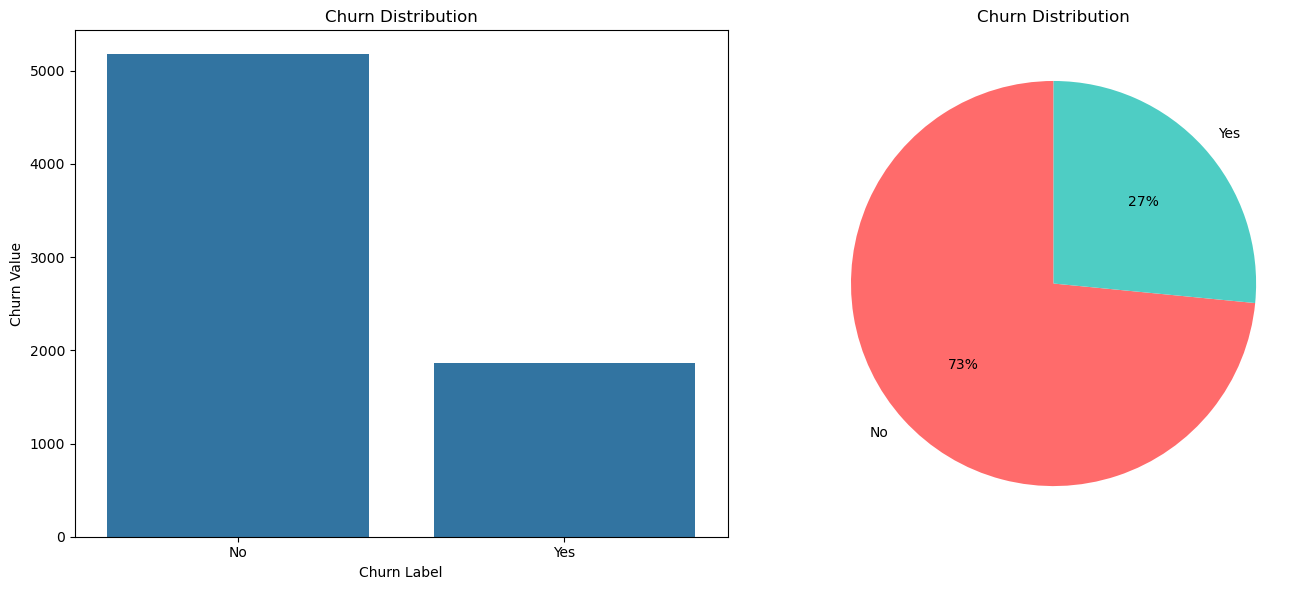

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
sns.barplot(data=label, x='churn_label', y='churn_value', ax=ax1)
ax1.set(
    title='Churn Distribution',
    xlabel='Churn Label',
    ylabel='Churn Value'
)

ax2.pie(
    label['churn_value'],
    labels=label.index,
    autopct='%1.f%%',
    startangle=90,
    colors=['#ff6b6b', '#4ecdc4']
)
ax2.set_title('Churn Distribution')
# plt.savefig('churn_distribution.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
# biggest reasons why people churn
reason = main_df.groupby('churn_reason')[['churn_value']].count()
greater_than_100 = reason['churn_value'] > 100
highest_reason = reason[greater_than_100]
# highest_reason

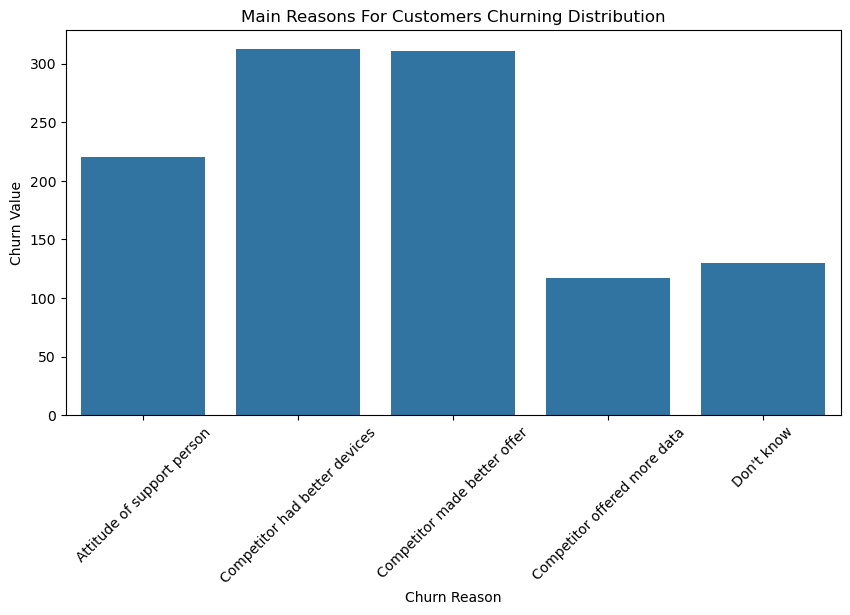

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.barplot(data=highest_reason, x=highest_reason.index, y='churn_value')
ax.set(
    title='Main Reasons For Customers Churning Distribution',
    xlabel='Churn Reason',
    ylabel='Churn Value'
)
# plt.savefig('churn_reasons.png', dpi=300, bbox_inches='tight')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Which churn categories contribute most to customer loss?
churned_df = main_df[main_df['churn_value'] == 1]
categories = churned_df.groupby('churn_category')['churn_value'].count()

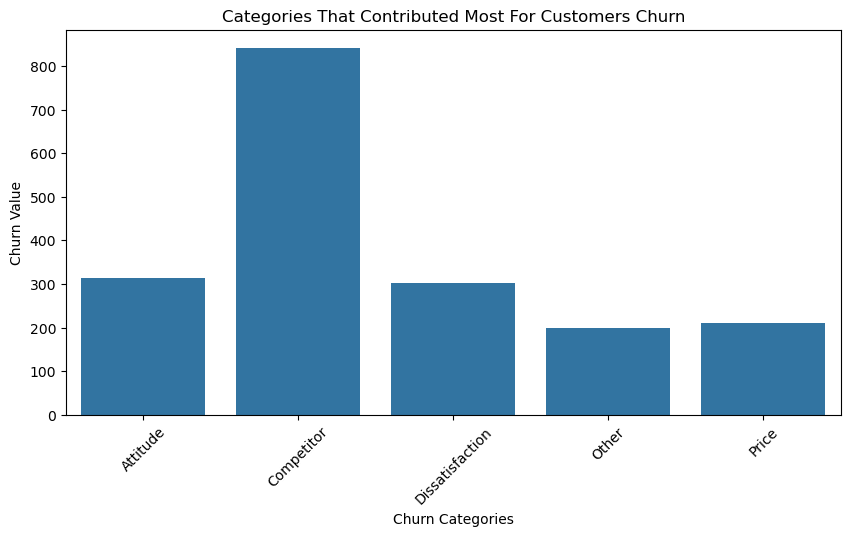

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x=categories.index, y=categories.values)
ax.set(
    title='Categories That Contributed Most For Customers Churn',
    xlabel='Churn Categories',
    ylabel='Churn Value'
)

plt.xticks(rotation=45)
plt.show()

In [ ]:
# What is the percentage of customers that Churned, Stayed, or Newly Joined?
status = main_df['customer_status'].value_counts()
percentage = (status / len(main_df)) * 100

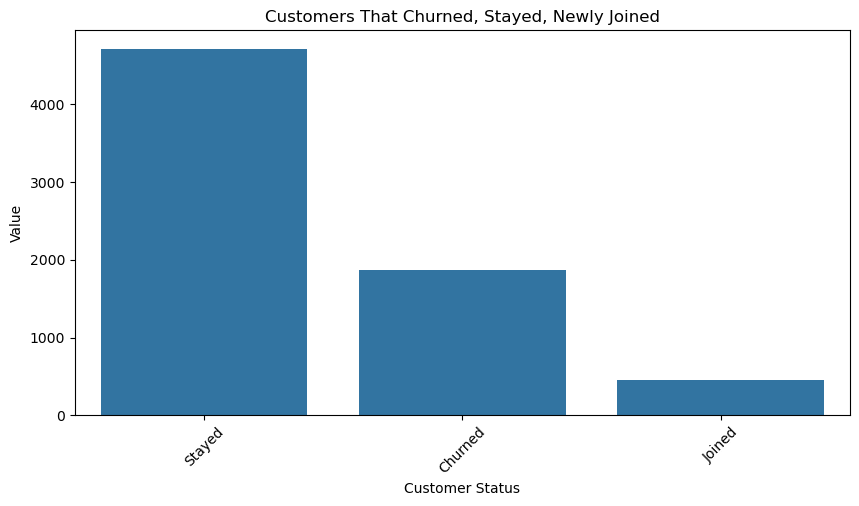

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x=status.index, y=status.values)
ax.set(
    title='Customers That Churned, Stayed, Newly Joined',
    xlabel='Customer Status',
    ylabel='Value'
)

plt.xticks(rotation=45)
plt.show()

In [ ]:
# What is the distribution of churn_score?
distribution_churn_score = main_df['churn_score'].value_counts()
# distribution_churn_score

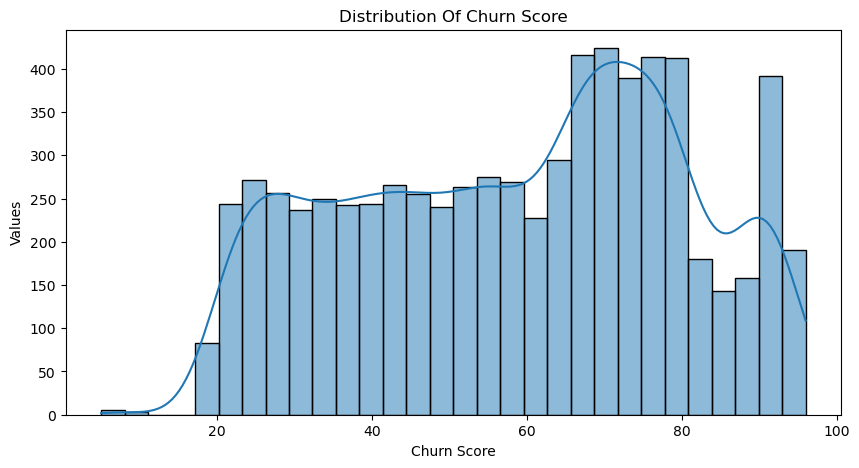

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.histplot(data=main_df, x='churn_score', bins=30, kde=True)
ax.set(
    title='Distribution Of Churn Score',
    xlabel='Churn Score',
    ylabel='Values'
)

plt.show()

In [ ]:
# Are higher churn scores actually linked to churn_value = 1?
check_score = main_df.groupby('churn_score')[['churn_value']].mean()
# check_score

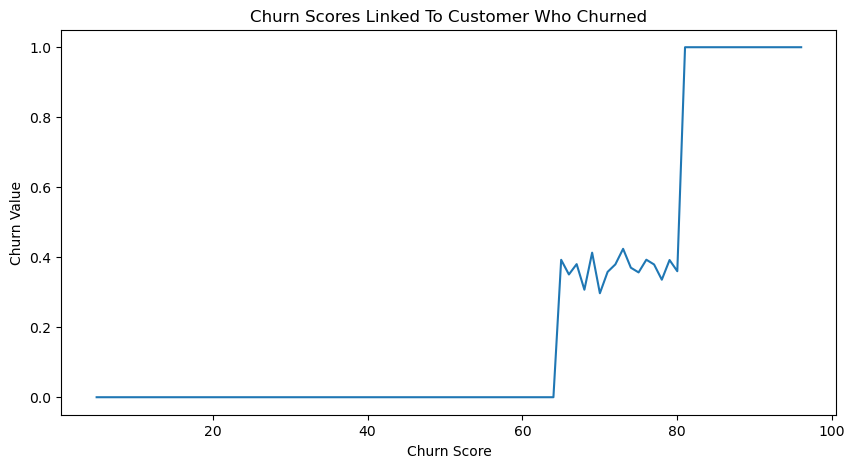

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.lineplot(data=check_score, x=check_score.index, y='churn_value')
ax.set(
    title='Churn Scores Linked To Customer Who Churned',
    xlabel='Churn Score',
    ylabel='Churn Value'
)

plt.show()

In [ ]:
# What churn_score range is the danger zone (where churn rate becomes high)?
churn_zone = main_df.groupby('churn_score')[['churn_value']].mean()
danger_zone = (churn_zone  * 100)
# danger_zone

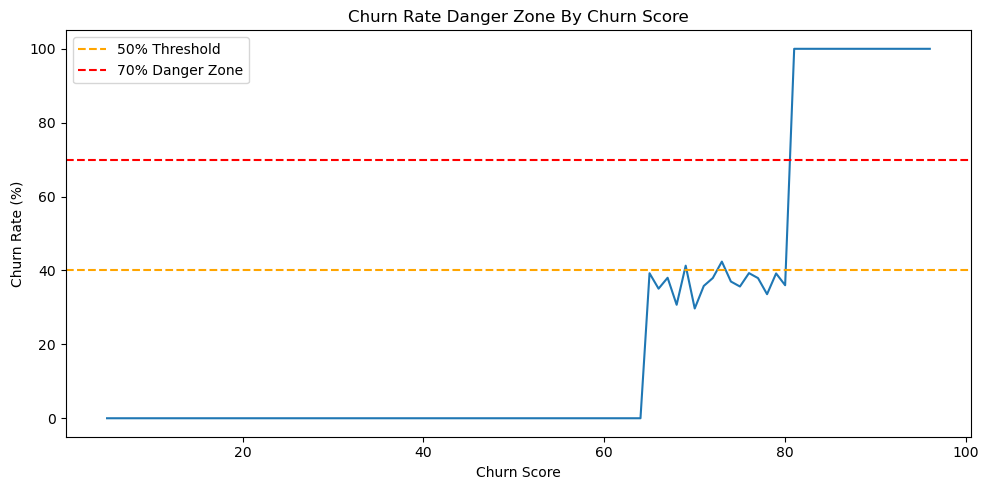

In [ ]:
plt.figure(figsize=(10, 5))
ax = sns.lineplot(x=danger_zone.index, y=danger_zone['churn_value'])
ax.axhline(y=40, color='orange', linestyle='--', label='50% Threshold')
ax.axhline(y=70, color='red', linestyle='--', label='70% Danger Zone')
ax.legend()
ax.set(
    title='Churn Rate Danger Zone By Churn Score',
    xlabel='Churn Score',
    ylabel='Churn Rate (%)'
)
plt.tight_layout()
plt.show()

In [ ]:
# Where does churn rate starts rising sharply?
rising_point = danger_zone['churn_value'].diff()
rising_point[rising_point  > 10]

churn_score
65    39.259259
69    10.590062
81    64.000000
Name: churn_value, dtype: float64

In [ ]:
# what is your trigger point?
trigger_point = rising_point[rising_point  > 10]
print(f"The trigger point is {trigger_point.index[0]}")

The trigger point is 65


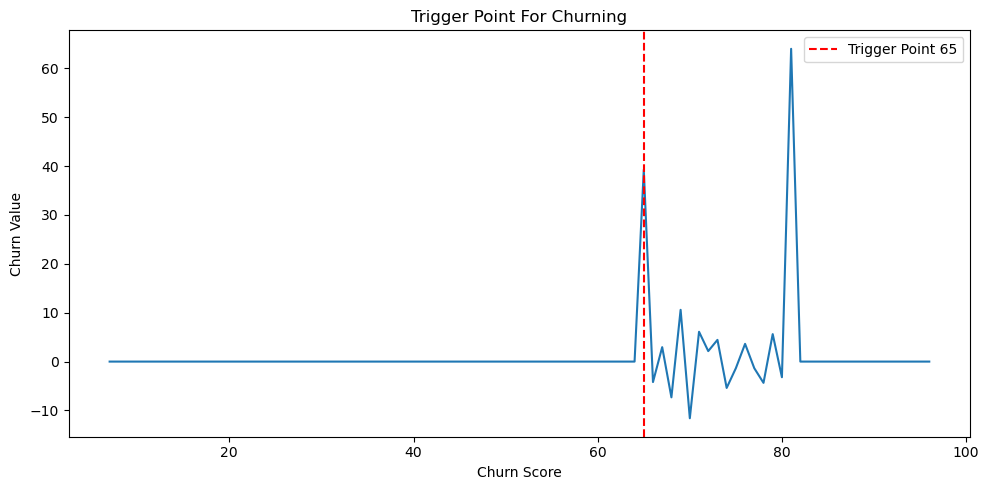

In [ ]:
plt.figure(figsize=(10,5))
ax = sns.lineplot(x=rising_point.index, y=rising_point.values)
ax.axvline(x=trigger_point.index[0], color='red', linestyle='--', label=f'Trigger Point {trigger_point.index[0]}')
ax.legend()
ax.set(
    title='Trigger Point For Churning',
    xlabel='Churn Score',
    ylabel='Churn Value'
)
# plt.savefig('trigger_point.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
# What is the revenue loss from churned customers?
revenue_lost = churned_df['total_revenue'].sum()
future_revenue_lost = churned_df['cltv'].sum()
monthly_charges_lost = churned_df['monthly_charges'].sum()
print(f'Revenue lost is ${revenue_lost}')
print(f'Future revenue lost is ${future_revenue_lost}')
print(f'Monthly revenue lost is ${monthly_charges_lost}')

Revenue lost is $3684459.8200000003
Future revenue lost is $7755256
Monthly revenue lost is $139130.85


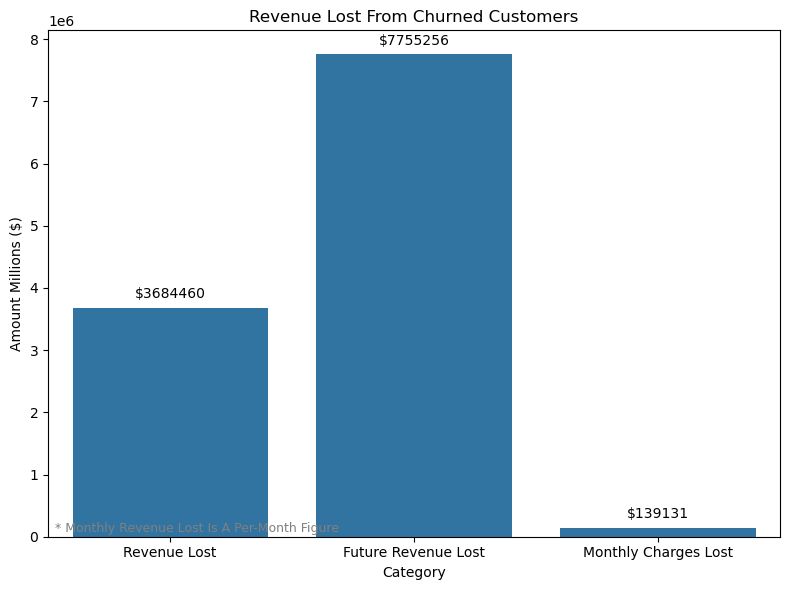

In [ ]:
revenue_data = pd.DataFrame({
    'category':['Revenue Lost', 'Future Revenue Lost', 'Monthly Charges Lost'],
    'values':[revenue_lost, future_revenue_lost, monthly_charges_lost]
})

plt.figure(figsize=(8,6))
ax = sns.barplot(data=revenue_data, x='category', y='values')

for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=5)

ax.set(
    title='Revenue Lost From Churned Customers',
    xlabel='Category',
    ylabel='Amount Millions ($)'
)

ax.annotate(
    '* Monthly Revenue Lost Is A Per-Month Figure',
    xy=(0.01, 0.01),
    xycoords='axes fraction',
    fontsize=9,
    color='gray'
)
# plt.savefig('revenue_lost.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

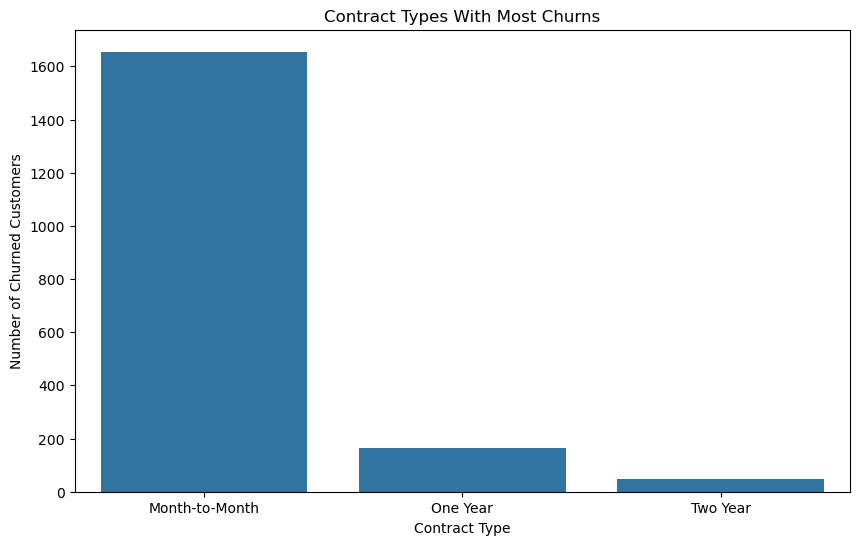

In [ ]:
# contract type that churns more
contract_df = churned_df['contract'].value_counts()

plt.figure(figsize=(10,6))
ax = sns.barplot(x=contract_df.index, y=contract_df.values)
ax.set(
    title='Contract Types With Most Churns',
    xlabel='Contract Type',
    ylabel='Number of Churned Customers'
)
# plt.savefig('contract_type_churns.png', dpi=300, bbox_inches='tight')
plt.show()

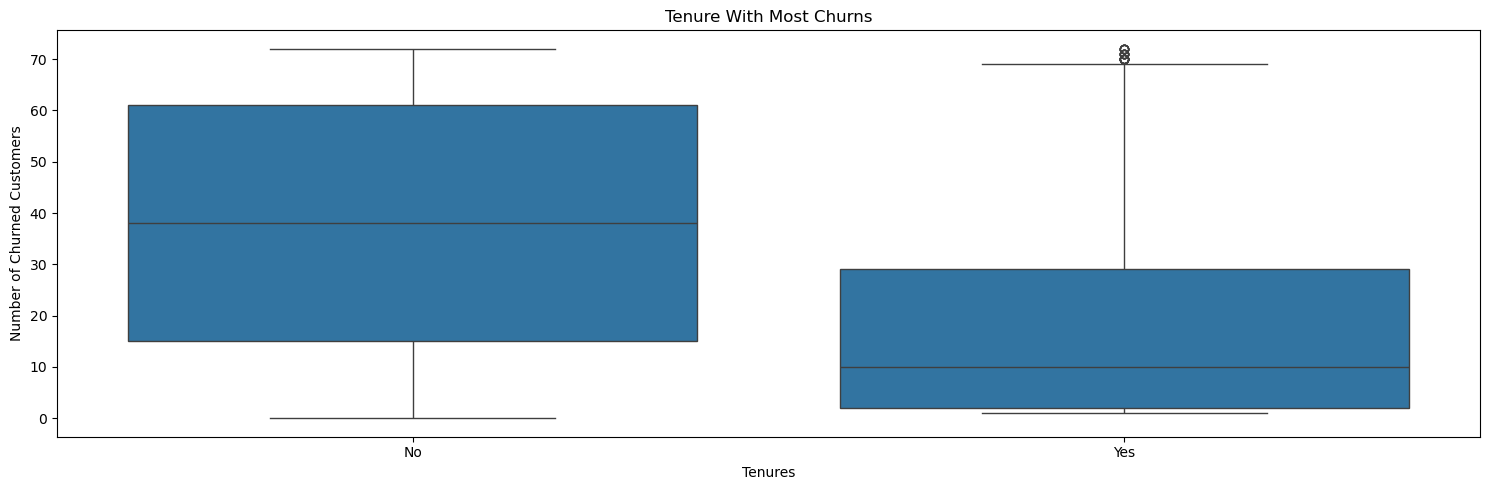

In [ ]:
# using tenure to checks churns
plt.figure(figsize=(15,5))
ax = sns.boxplot(data=main_df, x='churn_label', y='tenure')
ax.set(
   title='Tenure With Most Churns',
    xlabel='Tenures',
    ylabel='Number of Churned Customers'
)

plt.tight_layout()
plt.show()

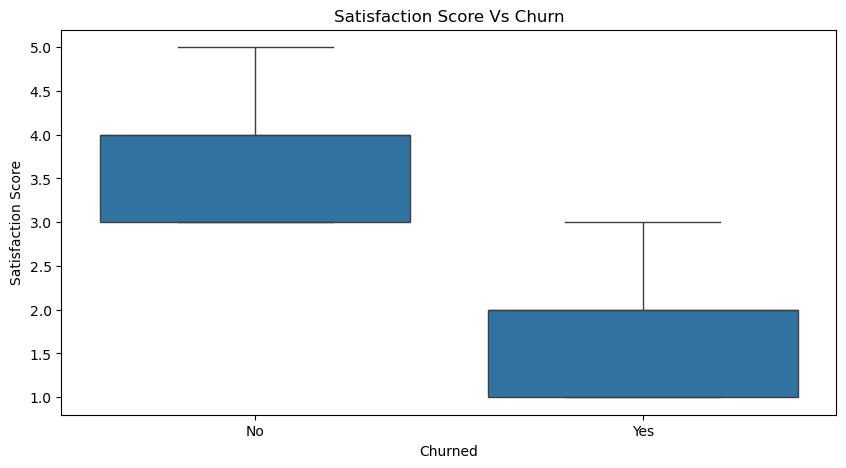

In [ ]:
# Does satisfaction score affect churning
plt.figure(figsize=(10,5))
ax = sns.boxplot(data=main_df, x='churn_label', y='satisfaction_score')
ax.set(
    title='Satisfaction Score Vs Churn',
    xlabel='Churned',
    ylabel='Satisfaction Score'
)
plt.show()

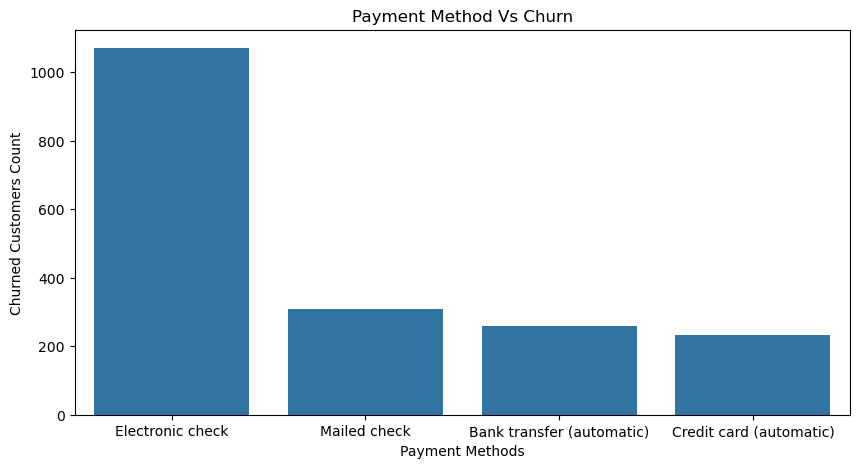

In [ ]:
# payment method vs churning
payment = churned_df['payment_method'].value_counts()
plt.figure(figsize=(10,5))
ax = sns.barplot(x=payment.index, y=payment.values)
ax.set(
    title='Payment Method Vs Churn',
    xlabel='Payment Methods',
    ylabel='Churned Customers Count'
)
plt.show()

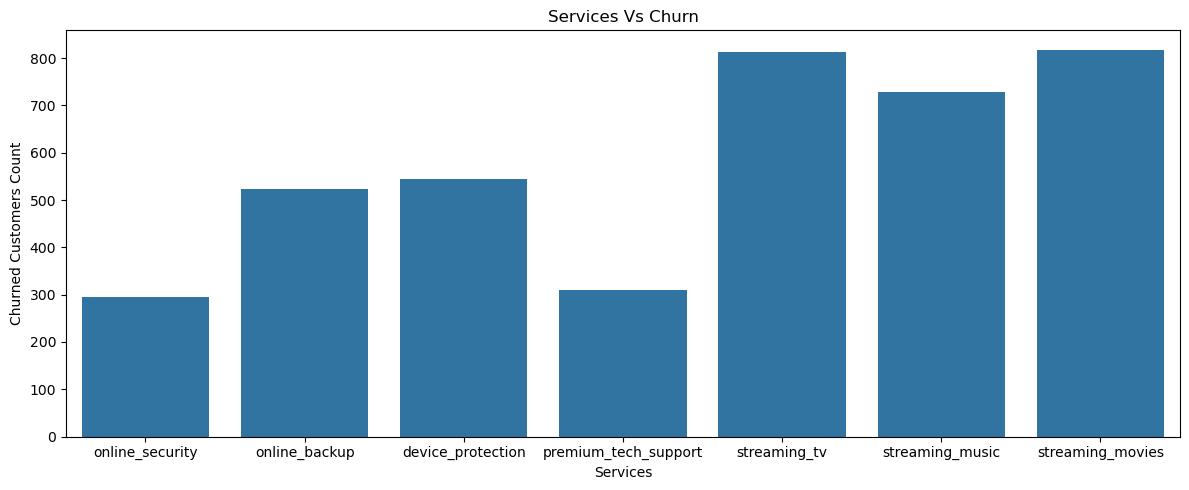

In [ ]:
# services vs churn
service_cols = ['online_security', 'online_backup', 'device_protection',
                'premium_tech_support', 'streaming_tv', 'streaming_music', 'streaming_movies']

# Melt into long format
services_melted = churned_df[service_cols].melt(var_name='service', value_name='status')

# Keep only customers who had the service
services_yes = services_melted[services_melted['status'] == 'Yes']

plt.figure(figsize=(12, 5))
ax = sns.countplot(data=services_yes, x='service')
ax.set(
    title='Services Vs Churn',
    xlabel='Services',
    ylabel='Churned Customers Count'
)
plt.tight_layout()
plt.show()

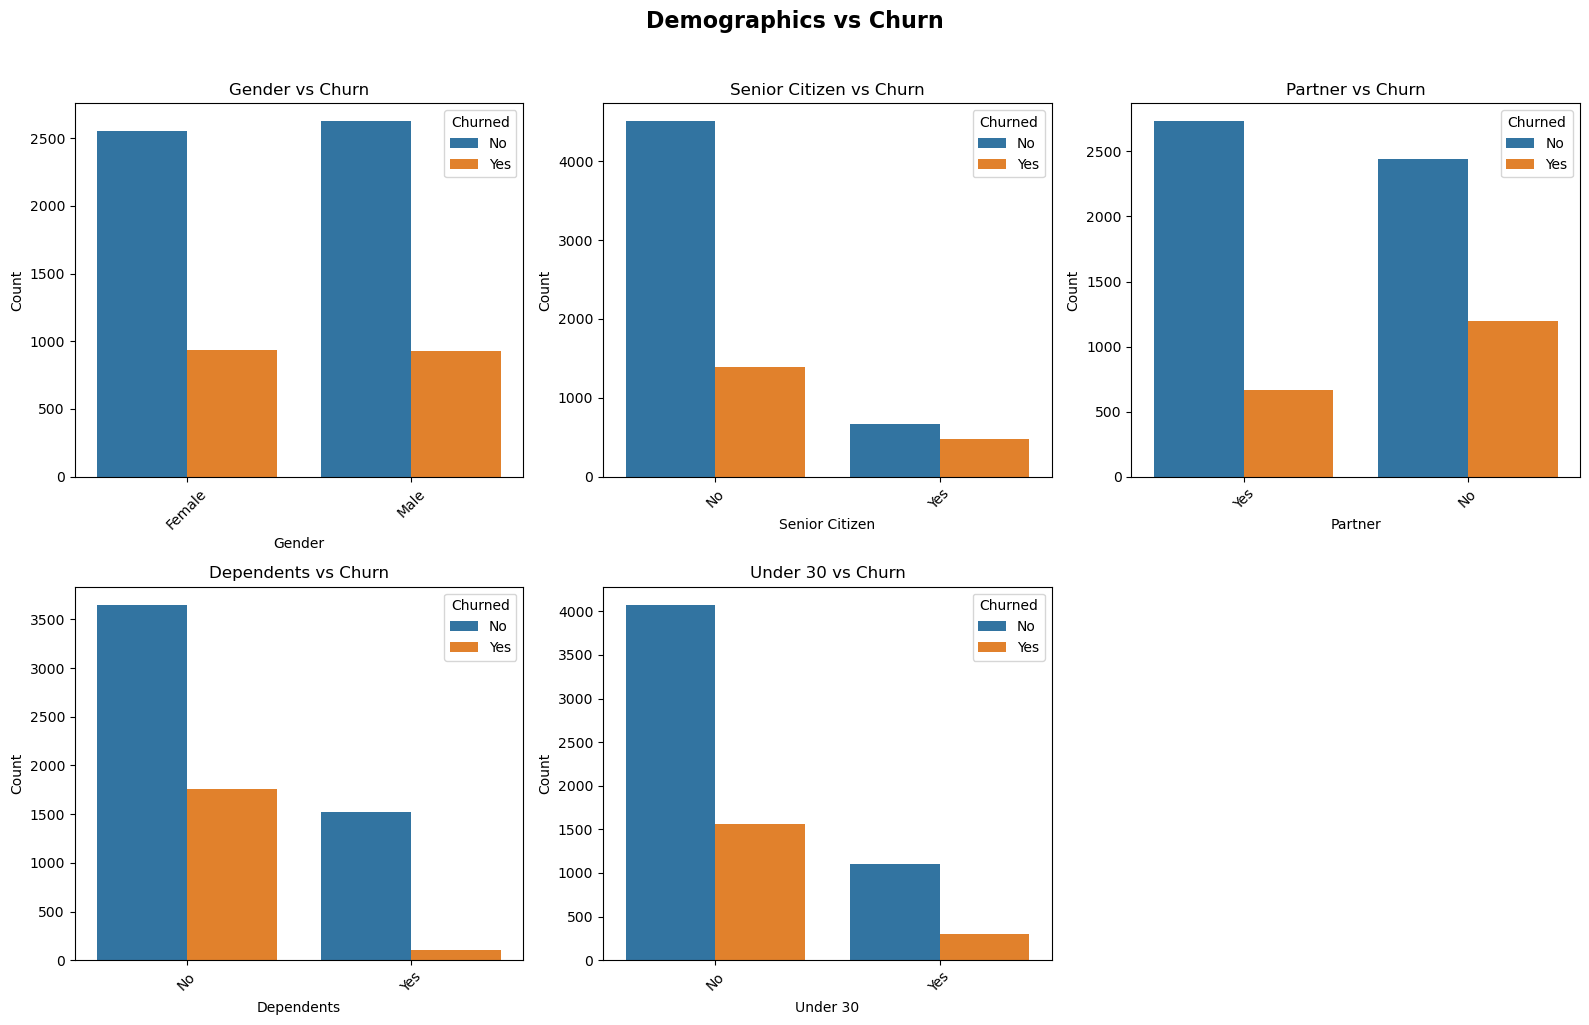

In [ ]:
# Demographic vs churn
demo_cols = ['gender', 'senior_citizen', 'partner', 'dependents', 'under_30']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # makes it easier to loop through

for i, col in enumerate(demo_cols):
    sns.countplot(data=main_df, x=col, hue='churn_label', ax=axes[i])
    axes[i].set(
        title=f'{col.replace("_", " ").title()} vs Churn',
        xlabel=col.replace("_", " ").title(),
        ylabel='Count'
    )
    axes[i].legend(title='Churned', labels=['No', 'Yes'])
    axes[i].tick_params(axis='x', rotation=45)

# Hide the empty 6th subplot
axes[5].set_visible(False)

plt.suptitle('Demographics vs Churn', fontsize=16, fontweight='bold', y=1.02)
# plt.savefig('demograph_vs_churn.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## Data Splitting, Data Encoding and Model Training

In [ ]:
"""
Dropping some columns not needed for the model encoding and training
"""

drop_cols = ['customer_id', 'latitude', 'longitude', 'zip_code', 'country',
             'state', 'city', 'churn_label', 'churn_score', 'churn_category',
             'churn_reason', 'offer', 'under_30', 'total_population',
            'number_of_dependents', 'customer_status']

main_df = main_df.drop(columns=drop_cols)

In [ ]:
# features to be used and target
x = main_df.drop(columns=['churn_value'])
y = main_df['churn_value']

# data splitting
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [ ]:
# label encoding
binary_cols = [
    # 'gender',
    'senior_citizen',
    'partner',
    'dependents',
    'online_security',
    'online_backup',
    'device_protection',
    'premium_tech_support',
    'streaming_tv',
    'streaming_movies',
    'streaming_music',
    'paperless_billing',
    'phone_service',
    'multiple_lines',
    'unlimited_data',
    'internet_service',
    'referred_a_friend'
]

# gender encoding
x_train['gender'] = x_train['gender'].map({'Male':1, 'Female':0})
x_test['gender'] = x_test['gender'].map({'Male':1, 'Female':0})

print("-----------------------------------------------------------------")

# encoding of the nominal columns
for col in binary_cols:
    print(f'{col} - the unique values are {x_train[col].unique()}')
    x_train[col] = x_train[col].map({'Yes':1, 'No':0})
    x_test[col] = x_test[col].map({'Yes':1, 'No':0})


-----------------------------------------------------------------
senior_citizen - the unique values are ['No' 'Yes']
partner - the unique values are ['Yes' 'No']
dependents - the unique values are ['Yes' 'No']
online_security - the unique values are ['Yes' 'No']
online_backup - the unique values are ['Yes' 'No']
device_protection - the unique values are ['No' 'Yes']
premium_tech_support - the unique values are ['No' 'Yes']
streaming_tv - the unique values are ['Yes' 'No']
streaming_movies - the unique values are ['No' 'Yes']
streaming_music - the unique values are ['No' 'Yes']
paperless_billing - the unique values are ['No' 'Yes']
phone_service - the unique values are ['Yes' 'No']
multiple_lines - the unique values are ['No' 'Yes']
unlimited_data - the unique values are ['Yes' 'No']
internet_service - the unique values are ['Yes' 'No']
referred_a_friend - the unique values are ['Yes' 'No']


In [ ]:
# one hot encoding
nominal_cols = [
    'internet_type',
    'contract',
    'payment_method',
]

print("-----------------------------------------------------------------")

for col in nominal_cols:
    print(f'{col} - the unique values are {x_train[col].unique()}')


ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

# fit on train, transform on both
train_encoded = ohe.fit_transform(x_train[nominal_cols])
test_encoded = ohe.transform(x_test[nominal_cols])

# convert from array to DataFrame with proper column names
train_encoded_df = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=x_train.index
)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(nominal_cols),
    index=x_test.index
)

# drop original columns and add the encoded columns
x_train = x_train.drop(columns=nominal_cols)
x_test = x_test.drop(columns=nominal_cols)

x_train = pd.concat([x_train, train_encoded_df], axis=1)
x_test = pd.concat([x_test, test_encoded_df], axis=1)

print(f'Training set shape {x_train.shape}')
print(f'Testing set shape {x_test.shape}')

-----------------------------------------------------------------
internet_type - the unique values are ['Fiber Optic' 'DSL' 'No internet' 'Cable']
contract - the unique values are ['Month-to-Month' 'One Year' 'Two Year']
payment_method - the unique values are ['Electronic check' 'Credit card (automatic)' 'Mailed check'
 'Bank transfer (automatic)']
Training set shape (5634, 41)
Testing set shape (1409, 41)


In [ ]:
# model training

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

rf_train_pred = rf.predict(x_train)
rf_test_pred = rf.predict(x_test)

print('_____ Random Forest ______')
print(f'Train Accuracy: {accuracy_score(y_train, rf_train_pred):.3f}')
print(f'Test Accuracy: {accuracy_score(y_test, rf_test_pred):.3f}')
print(f'Gap: {accuracy_score(y_train, rf_train_pred) - accuracy_score(y_test, rf_test_pred):.3f}')
print(f'F1 Score: {f1_score(y_test, rf_test_pred):.3f}')
print(f'Precision: {precision_score(y_test, rf_test_pred):.3f}')
print(f'Recall: {recall_score(y_test, rf_test_pred):.3f}')

_____ Random Forest ______
Train Accuracy: 1.000
Test Accuracy: 0.958
Gap: 0.042
F1 Score: 0.917
Precision: 0.967
Recall: 0.871


In [ ]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
# tuning the model using random search cv to get the best parameters
param_distributions = {
    'n_estimators':[200,300,400],
    'max_depth':[15,20,25],
    'min_samples_split':[5,10,15],
    'min_samples_leaf':[2,4,8]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    cv=5,
    n_iter=20,
    scoring='recall',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(x_train,y_train)

print(f'\n Best Parameter: {random_search.best_params_}')
print(f'Best CV: {random_search.best_score_:.3f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

 Best Parameter: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 15}
Best CV: 0.874


In [ ]:
best_rf = random_search.best_estimator_
best_rf.fit(x_train,y_train)

train_proba = best_rf.predict_proba(x_train)[:, 1]
test_proba = best_rf.predict_proba(x_test)[:, 1]

threshold = 0.4

best_train_pred = (train_proba >= threshold).astype(int)
best_test_pred = (test_proba >= threshold).astype(int)

print('_____ Tuned Random Forest ______')
print(f'Train Accuracy: {accuracy_score(y_train, best_train_pred):.3f}')
print(f'Test Accuracy:  {accuracy_score(y_test, best_test_pred):.3f}')
print(f'Gap:            {accuracy_score(y_train, best_train_pred) - accuracy_score(y_test, best_test_pred):.3f}')
print(f'Precision:      {precision_score(y_test, best_test_pred):.3f}')
print(f'Recall:         {recall_score(y_test, best_test_pred):.3f}')
print(f'F1 Score:       {f1_score(y_test, best_test_pred):.3f}')

_____ Tuned Random Forest ______
Train Accuracy: 0.994
Test Accuracy:  0.956
Gap:            0.038
Precision:      0.936
Recall:         0.895
F1 Score:       0.915


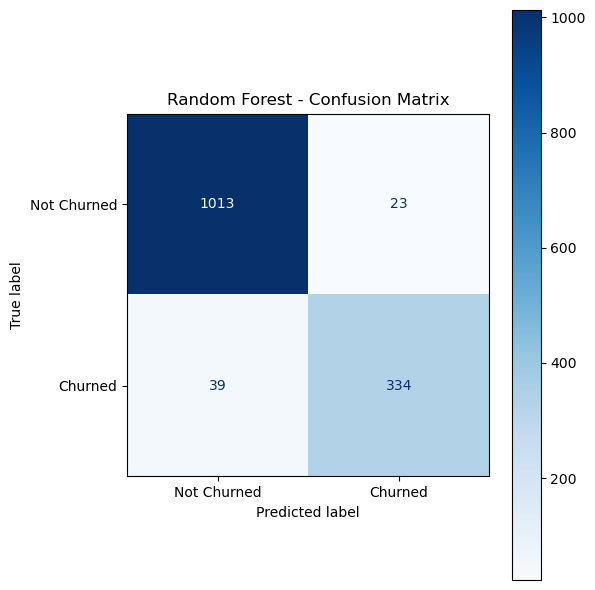

In [ ]:
cm = confusion_matrix(y_test, best_test_pred)

plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned', 'Churned'])
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Random Forest - Confusion Matrix')
plt.tight_layout()
# plt.savefig("random_forest_actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()

Out of 373 total churners, our model caught 334 and missed 39. At the same time it only raised a false alarm on 23 loyal customers.

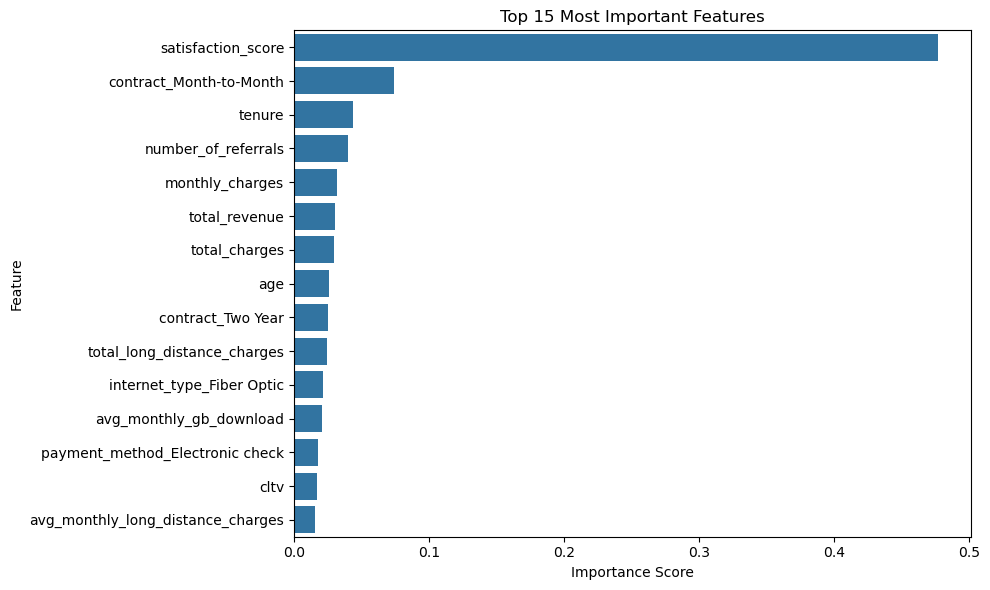

In [ ]:
# Build a DataFrame of features and their importance scores
importance_df = pd.DataFrame({
    'feature': x_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)  # top 15 only

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=importance_df, x='importance', y='feature')
ax.set(
    title='Top 15 Most Important Features',
    xlabel='Importance Score',
    ylabel='Feature'
)
# plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()